In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("pedidos_loja.csv")

In [3]:
df.head()

,id_pedido,data_pedido,id_cliente,canal,cidade,estado,categoria,produto,quantidade,preco_unitario,frete,status,data_entrega
0,PED-01169,2024-10-17,CLI-0394,site,Salvador,BA,esporte,Corda de Pular Speed,1,67.34,"R$ 28,06",entregue,2024-10-28
1,PED-01204,2024-08-02,CLI-0315,app,Brasília,DF,Casa & Decoração,"Tapete Sala 1,5m",4,214.43,"R$ 0,00",entregue,2024-08-16
2,PED-01464,2023-11-06,CLI-0223,app,Curitiba,PR,Moda,Jaqueta Jeans,4,188.97,"R$ 0,00",entregue,2023-11-16
3,PED-04480,2024-12-19,CLI-1293,app,Curitiba,PR,Beleza,Secador de Cabelo 2000W,1,192.99,"R$ 20,40",entregue,2025-01-02
4,PED-03605,2024-12-04,CLI-0958,site,Porto Alegre,RS,Beleza,Secador de Cabelo 2000W,2,336.47,"R$ 0,00",entregue,2024-12-16


In [4]:
df.shape

(5118, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5118 entries, 0 to 5117
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_pedido       5118 non-null   str    
 1   data_pedido     5118 non-null   str    
 2   id_cliente      5118 non-null   str    
 3   canal           5118 non-null   str    
 4   cidade          5087 non-null   str    
 5   estado          4955 non-null   str    
 6   categoria       5062 non-null   str    
 7   produto         5118 non-null   str    
 8   quantidade      5118 non-null   int64  
 9   preco_unitario  5047 non-null   float64
 10  frete           5118 non-null   str    
 11  status          5118 non-null   str    
 12  data_entrega    4249 non-null   str    
dtypes: float64(1), int64(1), str(11)
memory usage: 519.9 KB


In [6]:
df.describe()

,quantidade,preco_unitario
count,5118.000000,5047.000000
mean,1.961899,213.873662
std,1.098222,156.525215
min,-2.000000,-760.500000
25%,1.000000,100.310000
50%,2.000000,173.600000
75%,3.000000,288.355000
max,4.000000,898.360000


In [7]:
df.isna().sum()

id_pedido           0
data_pedido         0
id_cliente          0
canal               0
cidade             31
estado            163
categoria          56
produto             0
quantidade          0
preco_unitario     71
frete               0
status              0
data_entrega      869
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(118)

In [9]:
df["status"].value_counts()

status
entregue         3442
em transporte     421
cancelado         365
devolvido         282
Entregue          247
ENTREGUE          240
CANCELADO          29
Em transporte      22
Devolvido          22
EM TRANSPORTE      17
DEVOLVIDO          16
Cancelado          15
Name: count, dtype: int64

In [10]:
df["cidade"].nunique()

52

In [11]:
sorted(df["cidade"].dropna().unique())

['  Belo Horizonte ',
 '  Brasília ',
 '  Campinas ',
 '  Curitiba ',
 '  Fortaleza ',
 '  Goiânia ',
 '  Porto Alegre ',
 '  Recife ',
 '  Ribeirão Preto ',
 '  Rio de Janeiro ',
 '  Salvador ',
 '  São Paulo ',
 'BELO HORIZONTE',
 'BRASÍLIA',
 'Belo Horizonte',
 'Brasilia',
 'Brasília',
 'CAMPINAS',
 'CURITIBA',
 'Campinas',
 'Curitiba',
 'FORTALEZA',
 'Fortaleza',
 'GOIÂNIA',
 'Goiania',
 'Goiânia',
 'PORTO ALEGRE',
 'Porto Alegre',
 'RECIFE',
 'RIBEIRÃO PRETO',
 'RIO DE JANEIRO',
 'Recife',
 'Ribeirao Preto',
 'Ribeirão Preto',
 'Rio de Janeiro',
 'SALVADOR',
 'Salvador',
 'Sao Paulo',
 'SÃO PAULO',
 'São Paulo',
 'belo horizonte',
 'brasília',
 'campinas',
 'curitiba',
 'fortaleza',
 'goiânia',
 'porto alegre',
 'recife',
 'ribeirão preto',
 'rio de janeiro',
 'salvador',
 'são paulo']

## Diagnóstico inicial, 7 perguntas respondidas:
1) Quantas linhas e colunas tem a base?
5118, 13

2) preco_unitario e frete são do mesmo tipo de dado? Deveriam ser?
Não são do mesmo tipo de dado. preco é float64 e frete str. Float64 = número decimal = 74.43. Str = texto puro, pode ter número. Frete deveria ser Float64, pois entregou valores decimais com virgulas em forma de texto, não pode ser lido pelo pandas.

3) Por que describe() só resumiu 2 das 13 colunas?
Pq descibre só calcula colunas numéricas

4) A loja atende 12 cidades reais. Por que nunique() da coluna cidade deu 52?
Porque as cidades estão sem padronização de texto: Salvador x SALVADOR. O comando "sorted(df["cidade"].dropna().unique())" mostrou a diferença da grafia para as mesmas cidades.


5) Por que value_counts() do status mostrou mais de 4 categorias, se só existem 4 status possíveis?
Bom ela pede 4 categorias, mas listou algumas com o mesmo nome porém grafia diferente, em transporte x EM TRANSPORTE por exemplo. 

6) Existe algum valor de quantidade que não faz sentido pra um pedido?
No describe tem um pedido com quantidade negativa - 2

7) O duplicate().sum() deu 118, o que isso quer dizer na base?
Mostra o número exato de cópias exatas. 


In [12]:
df["frete"] = df["frete"].str.replace("R$ ", "", regex=False)
df["frete"] = df["frete"].str.replace(",", ".", regex=False)
df["frete"] = df["frete"].astype(float)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5118 entries, 0 to 5117
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_pedido       5118 non-null   str    
 1   data_pedido     5118 non-null   str    
 2   id_cliente      5118 non-null   str    
 3   canal           5118 non-null   str    
 4   cidade          5087 non-null   str    
 5   estado          4955 non-null   str    
 6   categoria       5062 non-null   str    
 7   produto         5118 non-null   str    
 8   quantidade      5118 non-null   int64  
 9   preco_unitario  5047 non-null   float64
 10  frete           5118 non-null   float64
 11  status          5118 non-null   str    
 12  data_entrega    4249 non-null   str    
dtypes: float64(2), int64(1), str(10)
memory usage: 519.9 KB


In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(5000, 13)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df["cidade"] = df["cidade"].str.strip()
df["cidade"] = df["cidade"].str.title()

In [18]:
df["cidade"].nunique()

16

In [19]:
sorted(df["cidade"].dropna().unique())

['Belo Horizonte',
 'Brasilia',
 'Brasília',
 'Campinas',
 'Curitiba',
 'Fortaleza',
 'Goiania',
 'Goiânia',
 'Porto Alegre',
 'Recife',
 'Ribeirao Preto',
 'Ribeirão Preto',
 'Rio De Janeiro',
 'Salvador',
 'Sao Paulo',
 'São Paulo']

In [20]:
import unicodedata
import pandas as pd

def remove_acentos(texto):
    if pd.isna(texto):
        return texto
    return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")

df["cidade"] = df["cidade"].apply(remove_acentos)

In [21]:
df["cidade"].nunique()

12

In [22]:
sorted(df["cidade"].dropna().unique())

['Belo Horizonte',
 'Brasilia',
 'Campinas',
 'Curitiba',
 'Fortaleza',
 'Goiania',
 'Porto Alegre',
 'Recife',
 'Ribeirao Preto',
 'Rio De Janeiro',
 'Salvador',
 'Sao Paulo']

In [23]:
sorted(df["categoria"].dropna().unique())

['BELEZA',
 'Beleza',
 'CASA & DECORAÇÃO',
 'Casa & Decoração',
 'ELETRÔNICOS',
 'ESPORTE',
 'Eletrônicos',
 'Esporte',
 'MODA',
 'Moda',
 'beleza',
 'casa & decoracao',
 'eletronicos',
 'esporte',
 'moda']

In [24]:
sorted(df["status"].dropna().unique())


['CANCELADO',
 'Cancelado',
 'DEVOLVIDO',
 'Devolvido',
 'EM TRANSPORTE',
 'ENTREGUE',
 'Em transporte',
 'Entregue',
 'cancelado',
 'devolvido',
 'em transporte',
 'entregue']

In [25]:
df["status"] = df["status"].str.strip()
df["status"] = df["status"].str.title()

In [26]:
df["categoria"] = df["categoria"].str.strip()
df["categoria"] = df["categoria"].str.title()

In [27]:
df["categoria"] = df["categoria"].apply(remove_acentos)

In [28]:
df["status"].nunique()

4

In [29]:
df["categoria"].nunique()

5

In [30]:
df[df["quantidade"] <= 0]

,id_pedido,data_pedido,id_cliente,canal,cidade,estado,categoria,produto,quantidade,preco_unitario,frete,status,data_entrega
59,PED-00980,2023-07-10,CLI-0254,site,Rio De Janeiro,RJ,Casa & Decoracao,Luminária de Mesa LED,0,127.24,17.22,Cancelado,NaN
105,PED-03945,2023-07-01,CLI-0777,marketplace,Sao Paulo,SP,Esporte,Tapete de Yoga 6mm,0,188.14,16.23,Entregue,2023-07-05
170,PED-00905,2024-12-14,CLI-1344,marketplace,Sao Paulo,SP,Esporte,Garrafa Térmica 1L,-2,71.91,14.89,Entregue,2024-12-28
215,PED-02507,2024-12-06,CLI-0638,site,Sao Paulo,SP,Moda,Tênis Casual Masculino,-1,341.01,0.00,Entregue,2024-12-09
519,PED-00930,2024-08-20,CLI-1348,app,Curitiba,PR,Casa & Decoracao,Jogo de Toalhas 4 peças,0,185.98,0.00,Entregue,2024-09-03
933,PED-01835,2023-08-08,CLI-0533,app,Rio De Janeiro,RJ,Casa & Decoracao,Luminária de Mesa LED,0,198.74,21.52,Entregue,2023-08-17
1038,PED-00113,2023-10-29,CLI-0607,app,Ribeirao Preto,SP,Beleza,Kit Skincare Facial,-1,-260.59,0.00,Entregue,2023-11-04
1059,PED-02896,2023-04-08,CLI-0281,app,Rio De Janeiro,RJ,Eletronicos,Webcam Full HD,-2,324.57,0.00,Entregue,2023-04-11
1129,PED-04077,2024-06-19,CLI-1262,app,Sao Paulo,SP,Esporte,Tapete de Yoga 6mm,-1,171.73,19.57,Cancelado,NaN
1163,PED-00537,2024-03-24,CLI-0428,site,Brasilia,DF,Beleza,Kit Skincare Facial,0,219.78,0.00,Entregue,2024-04-09


In [31]:
quantidade_invalida = df[df["quantidade"] <= 0]
quantidade_invalida.to_csv("quantidade_invalida_revisar.csv", index=False)

In [32]:
df = df[df["quantidade"] > 0]

In [33]:
df.shape

(4955, 13)

In [34]:
df["quantidade"].min()

np.int64(1)

In [35]:
df.isna().sum()

id_pedido           0
data_pedido         0
id_cliente          0
canal               0
cidade             30
estado            160
categoria          55
produto             0
quantidade          0
preco_unitario     70
frete               0
status              0
data_entrega      851
dtype: int64

In [36]:
df[df["data_entrega"].isna()]["status"].value_counts()

status
Em Transporte    452
Cancelado        399
Name: count, dtype: int64

In [37]:
df[df["cidade"].isna()]["estado"].isna().sum()

np.int64(0)

In [38]:
df.groupby("estado")["cidade"].nunique()

estado
BA    1
CE    1
DF    1
GO    1
MG    1
PE    1
PR    1
RJ    1
RS    1
SP    3
Name: cidade, dtype: int64

In [39]:
df[df["cidade"].isna()]["estado"].value_counts()

estado
SP    14
PR     9
CE     2
RJ     2
RS     1
MG     1
PE     1
Name: count, dtype: int64

In [40]:
df.groupby("estado")["cidade"].unique()

estado
BA                                    [Salvador]
CE                              [Fortaleza, nan]
DF                                    [Brasilia]
GO                                     [Goiania]
MG                         [Belo Horizonte, nan]
PE                                 [Recife, nan]
PR                               [Curitiba, nan]
RJ                         [Rio De Janeiro, nan]
RS                           [Porto Alegre, nan]
SP    [Sao Paulo, Campinas, Ribeirao Preto, nan]
Name: cidade, dtype: object

In [41]:
mapa_estado_cidade = {
    "BA": "Salvador",
    "CE": "Fortaleza",
    "DF": "Brasilia",
    "GO": "Goiania",
    "MG": "Belo Horizonte",
    "PE": "Recife",
    "PR": "Curitiba",
    "RJ": "Rio De Janeiro",
    "RS": "Porto Alegre",
}

In [42]:
cidade_recuperada = df["estado"].map(mapa_estado_cidade)
df["cidade"] = df["cidade"].fillna(cidade_recuperada)

In [43]:
df["cidade"].isna().sum()

np.int64(14)

In [44]:
cidade_para_estado = {
    "Salvador": "BA",
    "Fortaleza": "CE",
    "Brasilia": "DF",
    "Goiania": "GO",
    "Belo Horizonte": "MG",
    "Recife": "PE",
    "Curitiba": "PR",
    "Rio De Janeiro": "RJ",
    "Porto Alegre": "RS",
    "Sao Paulo": "SP",
    "Campinas": "SP",
    "Ribeirao Preto": "SP",
}

estado_recuperado = df["cidade"].map(cidade_para_estado)
df["estado"] = df["estado"].fillna(estado_recuperado)

In [45]:
df["estado"].isna().sum()

np.int64(0)

In [46]:
cidade_ou_preco_invalido = df[df["cidade"].isna() | df["preco_unitario"].isna()]
cidade_ou_preco_invalido.to_csv("cidade_preco_invalido_revisar.csv", index=False)


In [47]:
df = df[df["cidade"].notna() & df["preco_unitario"].notna()]


In [48]:
df.shape

(4871, 13)

In [49]:
df.isna().sum()

id_pedido           0
data_pedido         0
id_cliente          0
canal               0
cidade              0
estado              0
categoria          53
produto             0
quantidade          0
preco_unitario      0
frete               0
status              0
data_entrega      836
dtype: int64

In [50]:
df.groupby("produto")["categoria"].nunique()

produto
Base Líquida Matte            1
Boné Aba Curva                1
Caixa de Som Portátil         1
Camiseta Básica Algodão       1
Camiseta Dry Fit              1
Carregador Turbo 30W          1
Corda de Pular Speed          1
Fone Bluetooth TWS            1
Garrafa Térmica 1L            1
Halter Emborrachado 5kg       1
Jaqueta Jeans                 1
Jogo de Toalhas 4 peças       1
Kit Skincare Facial           1
Luminária de Mesa LED         1
Mochila Notebook 15"          1
Perfume Importado 100ml       1
Quadro Decorativo Abstrato    1
Secador de Cabelo 2000W       1
Smartwatch Fit                1
Tapete Sala 1,5m              1
Tapete de Yoga 6mm            1
Tênis Casual Masculino        1
Vaso Decorativo Cerâmica      1
Webcam Full HD                1
Name: categoria, dtype: int64

In [51]:
produto_para_categoria = df.dropna(subset=["categoria"]).drop_duplicates(subset=["produto"]).set_index("produto")["categoria"]

In [52]:
categoria_recuperada = df["produto"].map(produto_para_categoria)
df["categoria"] = df["categoria"].fillna(categoria_recuperada)

In [53]:
df["categoria"].isna().sum()

np.int64(0)

In [54]:
df.isna().sum()

id_pedido           0
data_pedido         0
id_cliente          0
canal               0
cidade              0
estado              0
categoria           0
produto             0
quantidade          0
preco_unitario      0
frete               0
status              0
data_entrega      836
dtype: int64

### Núcleo
1. Quais produtos vendem mais e menos?
2. Quais categorias vendem mais e menos?
3. Qual a taxa geral de cancelamento, e quais categorias cancelam mais e menos?
4. Quais estados compram mais e menos?
5. Qual canal vende mais e menos?
6. Como as vendas evoluem mês a mês?

### Avançado (cruzamentos)
7. Produtos mais/menos vendidos por estado
8. Produtos mais/menos vendidos por canal
9. Produtos mais/menos vendidos no mês de pico e no mês de vale

In [55]:
df["receita"] = df["quantidade"] * df["preco_unitario"]

In [56]:
df.groupby("produto")["quantidade"].sum().sort_values(ascending=False)

produto
Fone Bluetooth TWS            541
Smartwatch Fit                532
Webcam Full HD                520
Jaqueta Jeans                 514
Carregador Turbo 30W          505
Camiseta Básica Algodão       491
Boné Aba Curva                468
Mochila Notebook 15"          449
Secador de Cabelo 2000W       447
Caixa de Som Portátil         429
Vaso Decorativo Cerâmica      417
Tênis Casual Masculino        411
Tapete Sala 1,5m              400
Kit Skincare Facial           391
Perfume Importado 100ml       385
Quadro Decorativo Abstrato    375
Jogo de Toalhas 4 peças       366
Luminária de Mesa LED         349
Base Líquida Matte            337
Garrafa Térmica 1L            298
Camiseta Dry Fit              284
Corda de Pular Speed          264
Tapete de Yoga 6mm            254
Halter Emborrachado 5kg       238
Name: quantidade, dtype: int64

In [57]:
df.groupby("produto")["receita"].sum().sort_values(ascending=False)

produto
Smartwatch Fit                328193.83
Perfume Importado 100ml       162111.77
Caixa de Som Portátil         159002.38
Fone Bluetooth TWS            146663.15
Webcam Full HD                140084.19
Jaqueta Jeans                 122507.32
Tênis Casual Masculino        121021.38
Secador de Cabelo 2000W       115583.66
Tapete Sala 1,5m              113750.39
Mochila Notebook 15"          100114.33
Kit Skincare Facial            73331.69
Jogo de Toalhas 4 peças        64526.60
Luminária de Mesa LED          52174.90
Quadro Decorativo Abstrato     49604.84
Carregador Turbo 30W           47571.97
Vaso Decorativo Cerâmica       46691.66
Boné Aba Curva                 38727.80
Tapete de Yoga 6mm             36191.91
Base Líquida Matte             34005.98
Camiseta Básica Algodão        33847.46
Garrafa Térmica 1L             28772.39
Halter Emborrachado 5kg        26711.07
Camiseta Dry Fit               25661.18
Corda de Pular Speed           14480.52
Name: receita, dtype: float64

Os produtos mais vendidos em quantidade: Fone Bluetooth TWS, Smartwatch Fit, Webcam full HD, Jaqueta Jeans, Carregador Turbo 30w. Os produtos menos vendidos em quantidade, começando do menor: Halter Emborrachado 5kg, Tapete de Yoga 6mm, Corda de Pular speed, Camiseta dry fit, Garrafa térmica 1l. No top 3 mais vendidos por receita temos Smartwatch fit, perfume importado 100ml, caixa de som portátil. Nota-se a entrada de perfume importado e caixa de som portátil, mesmo ambos não aparecendo no top 5 de vendas, o valor deles gera muita receita. E os 3 com menos receita, começando do mais baixo: corda de pular speed, camiseta dry fit, halter emborrachado 5kg. Aqui já temos uma relação mais forte com o top 5 menos vendidos, os 3 aparecem na lista.

    

In [58]:
df.groupby("categoria")["quantidade"].sum().sort_values(ascending=False)

categoria
Eletronicos         2527
Moda                2333
Casa & Decoracao    1907
Beleza              1560
Esporte             1338
Name: quantidade, dtype: int64

In [59]:
df.groupby("categoria")["receita"].sum().sort_values(ascending=False)


categoria
Eletronicos         821515.52
Moda                416218.29
Beleza              385033.10
Casa & Decoracao    326748.39
Esporte             131817.07
Name: receita, dtype: float64

In [60]:
(df.groupby("categoria")["receita"].sum() / df.groupby("categoria")["quantidade"].sum()).sort_values(ascending=False)

categoria
Eletronicos         325.095180
Beleza              246.816090
Moda                178.404754
Casa & Decoracao    171.341578
Esporte              98.517990
dtype: float64

Analisando  as categorias mais e menos vendidas nos quesitos quantidade/receita e valor do ticket médio, pode-se notar: 1) Eletrônicos é o carro-chefe da loja, manter o investimento/marketing 2)Beleza é sólido, o ticket é alto e tem menos vendas, seria interessante aumentar o marketing e visibilidade, visto que tem gente disposta a pagar caro. 3) Esportes é o menos bem avaliado nos quesitos vistos, seria necessário uma aprofundação de estudo para entender o porque, se é a faixa de preço, se é a procura, nota-se que temos os produtos menos vendidos e com menos receita fazendo grande parte dessa categoria, talvez seja o valor mesmo que não possa ser equiparado com eletrônicos e beleza, que são naturalmente mais caros e vendidos.



In [61]:
total_pedidos = df.shape[0]
cancelados = (df["status"] == "Cancelado").sum()
taxa_cancelamento = cancelados / total_pedidos
taxa_cancelamento * 100

np.float64(7.9244508314514475)

In [62]:
df.groupby("categoria")["status"].value_counts(normalize=True)

categoria         status       
Beleza            Entregue         0.750939
                  Em Transporte    0.100125
                  Cancelado        0.078849
                  Devolvido        0.070088
Casa & Decoracao  Entregue         0.771520
                  Em Transporte    0.092455
                  Devolvido        0.069075
                  Cancelado        0.066950
Eletronicos       Entregue         0.770324
                  Cancelado        0.084451
                  Em Transporte    0.083662
                  Devolvido        0.061563
Esporte           Entregue         0.769457
                  Em Transporte    0.088106
                  Cancelado        0.086637
                  Devolvido        0.055800
Moda              Entregue         0.760778
                  Em Transporte    0.098901
                  Cancelado        0.079459
                  Devolvido        0.060862
Name: proportion, dtype: float64

In [63]:
df.groupby("categoria")["status"].value_counts(normalize=True).unstack()["Cancelado"].sort_values(ascending=False)

categoria
Esporte             0.086637
Eletronicos         0.084451
Moda                0.079459
Beleza              0.078849
Casa & Decoracao    0.066950
Name: Cancelado, dtype: float64

Em relação aos pedidos cancelados, a taxa de todos é 7,92%. Esporte 8,66% lidera. Casa & Decoração em último 6,69%. Não vejo uma discrepância muito grande entre as categorias. Nota-se esportes sendo o mais cancelado, menos vendido, e com menos receita. Talvez seja a categoria mais problemática da loja.



In [64]:
df.groupby("estado")["quantidade"].sum().sort_values(ascending=False)



estado
SP    3405
RJ    1150
MG     995
BA     729
RS     728
PR     706
CE     565
PE     529
DF     517
GO     341
Name: quantidade, dtype: int64

In [65]:
df.groupby("estado")["receita"].sum().sort_values(ascending=False)



estado
SP    750546.07
RJ    253906.76
MG    210306.82
BA    161483.02
RS    156739.33
PR    144376.82
CE    118801.57
PE    105658.79
DF    104025.64
GO     75487.55
Name: receita, dtype: float64

In [66]:
(df.groupby("estado")["receita"].sum() / df.groupby("estado")["quantidade"].sum()).sort_values(ascending=False)

estado
BA    221.513059
GO    221.371114
RJ    220.788487
SP    220.424690
RS    215.301277
MG    211.363638
CE    210.268265
PR    204.499745
DF    201.210135
PE    199.733062
dtype: float64

Nota-se que o resultado de quantidade acompanha perfeitamente o resultado de receita na comparação de estados. Nada anormal, o maior volume acompanha a maior receita. Pouca discrepância entre os valores de ticket médio (221 máximo x 199 mínimo).


In [67]:
df.groupby("canal")["quantidade"].sum().sort_values(ascending=False)



canal
site           4384
app            3401
marketplace    1880
Name: quantidade, dtype: int64

In [68]:
df.groupby("canal")["receita"].sum().sort_values(ascending=False)

canal
site           947832.27
app            715029.05
marketplace    418471.05
Name: receita, dtype: float64

In [69]:
(df.groupby("canal")["receita"].sum() / df.groupby("canal")["quantidade"].sum()).sort_values(ascending=False)


canal
marketplace    222.590984
site           216.202616
app            210.240826
dtype: float64

Nota-se que os canais acompanham o volume/receita. Porém, no valor de ticket médio, o marketplace rouba a cena e aparece em primeiro lugar. Pode ter potencial de crescimento, ticket alto/pouco volume. Mas resta descobrir a causa do volume menor.

In [70]:
df["data_pedido"].head(20)

0     2024-10-17
1     2024-08-02
2     2023-11-06
3     2024-12-19
4     2024-12-04
5     2023-09-11
7     2024-06-16
8     11/11/2023
9     2024-09-07
10    2023-10-10
11    19/01/2023
12    2024-09-15
13    2024-06-18
14    2024-10-20
15    2024-06-26
16    2024-05-07
17    26/04/2024
18    08/05/2024
19    07/09/2024
20    21/03/2023
Name: data_pedido, dtype: str

In [71]:
tentativa_iso = pd.to_datetime(df["data_pedido"], format="%Y-%m-%d", errors="coerce")
tentativa_br = pd.to_datetime(df["data_pedido"], format="%d/%m/%Y", errors="coerce")

df["data_pedido"] = tentativa_iso.fillna(tentativa_br)

In [72]:
df["data_pedido"].dtype

dtype('<M8[us]')

In [73]:
tentativa_iso = pd.to_datetime(df["data_entrega"], format="%Y-%m-%d", errors="coerce")
tentativa_br = pd.to_datetime(df["data_entrega"], format="%d/%m/%Y", errors="coerce")

df["data_entrega"] = tentativa_iso.fillna(tentativa_br)

In [74]:
df["data_entrega"].dtype

dtype('<M8[us]')

In [75]:
df.groupby(df["data_pedido"].dt.to_period("M"))["quantidade"].sum()

data_pedido
2023-01    235
2023-02    226
2023-03    306
2023-04    301
2023-05    345
2023-06    330
2023-07    334
2023-08    300
2023-09    317
2023-10    342
2023-11    552
2023-12    524
2024-01    378
2024-02    335
2024-03    431
2024-04    392
2024-05    473
2024-06    370
2024-07    351
2024-08    392
2024-09    437
2024-10    449
2024-11    825
2024-12    720
Freq: M, Name: quantidade, dtype: int64

In [76]:
df.groupby(df["data_pedido"].dt.to_period("M"))["receita"].sum()

data_pedido
2023-01     52085.96
2023-02     44222.80
2023-03     64377.90
2023-04     59108.09
2023-05     74235.31
2023-06     75433.03
2023-07     63003.52
2023-08     64422.78
2023-09     70040.43
2023-10     75171.69
2023-11    130171.90
2023-12    117936.30
2024-01     79909.85
2024-02     66736.49
2024-03     85813.50
2024-04     80672.34
2024-05    115343.48
2024-06     77575.01
2024-07     66876.49
2024-08     76031.86
2024-09    102332.31
2024-10     98219.97
2024-11    178833.75
2024-12    162777.61
Freq: M, Name: receita, dtype: float64

Após fazer o cálculo a parte pode-se notar: 1) 2024 -> 5.553 vendas 2023 -> 4.112 vendas = 2024 teve um crescimento de aproximadamente 35% de vendas.
2023 -> TOP 3 Novembro 552, Dezembro 524, Maio 345 2024 -> TOP 3 Novembro 825, Dezembro 720, Maio 473. TOP 3 NEGATIVO 2023 -> Fevereiro 226, Janeiro 235, Agosto 300. TOP 3 NEGATIVO 2024 -> Fevereiro 335, Julho 351, Junho 370.  Dezembro e novembro sãos os que mais vendem por causa de Black Friday, Natal. E fevereiro aparece com mês com menos vendas em ambos os anos. Receita segue o mesmo padrão de volume.

In [77]:
tabela_produto_estado = df.pivot_table(
    index="produto",
    columns="estado",
    values="quantidade",
    aggfunc="sum"
)

In [78]:
tabela_produto_estado.isna().sum().sum()

np.int64(0)

In [79]:
tabela_produto_estado

estado,BA,CE,DF,GO,MG,PE,PR,RJ,RS,SP
produto,,,,,,,,,,
Base Líquida Matte,29,5,17,4,44,24,28,48,21,117
Boné Aba Curva,43,28,40,10,48,31,30,37,30,171
Caixa de Som Portátil,39,20,24,24,44,20,29,51,34,144
Camiseta Básica Algodão,61,35,21,18,42,21,26,70,36,161
Camiseta Dry Fit,12,23,15,8,38,13,29,39,21,86
Carregador Turbo 30W,21,20,38,17,60,29,29,38,59,194
Corda de Pular Speed,6,15,16,14,23,16,26,20,26,102
Fone Bluetooth TWS,54,26,19,25,40,39,39,64,44,191
Garrafa Térmica 1L,10,24,16,9,32,21,22,28,16,120


In [80]:
tabela_produto_estado.idxmax()

estado
BA    Camiseta Básica Algodão
CE    Secador de Cabelo 2000W
DF             Boné Aba Curva
GO         Fone Bluetooth TWS
MG       Carregador Turbo 30W
PE         Fone Bluetooth TWS
PR    Secador de Cabelo 2000W
RJ    Camiseta Básica Algodão
RS       Carregador Turbo 30W
SP             Smartwatch Fit
dtype: str

In [81]:
tabela_produto_estado.idxmin()

estado
BA       Corda de Pular Speed
CE         Base Líquida Matte
DF    Secador de Cabelo 2000W
GO    Halter Emborrachado 5kg
MG       Corda de Pular Speed
PE         Tapete de Yoga 6mm
PR         Tapete de Yoga 6mm
RJ       Corda de Pular Speed
RS         Tapete de Yoga 6mm
SP         Tapete de Yoga 6mm
dtype: str

Não existe uma preferência nacional por um produto específico, mas nota-se fone bluettooth tws, secador de cabelo, carregador turbo e camiseta básica algodão como campeões de venda. No cenário inverso, Corda de Pular Speed e Tapete de Yoga 6mm, Halter emborrachado 5kg, todos da categoria esporte, com o tapete de yoga sendo o campeão disparado em menor venda. Não dá para notar a diferença de vendas entre os colocados. 

In [82]:
tabela_produto_canal = df.pivot_table(
    index="produto",
    columns="canal",
    values="quantidade",
    aggfunc="sum"
)


In [83]:
tabela_produto_canal.isna().sum().sum()



np.int64(0)

In [84]:
tabela_produto_canal.idxmax()

canal
app            Carregador Turbo 30W
marketplace    Mochila Notebook 15"
site             Fone Bluetooth TWS
dtype: str

In [85]:
tabela_produto_canal.idxmin()

canal
app            Halter Emborrachado 5kg
marketplace    Halter Emborrachado 5kg
site                Garrafa Térmica 1L
dtype: str

Não existe um produto dominante nas vendas dos canais, cada canal tem um campeão a parte. Novamente produtos da categoria "esporte" dominando os que menos vendem em cada canal, com halter emborrachado 5kg sendo o campeão disparado. É a quinta vez que produtos da categoria "esporte" dominam a categoria de menos vendidos.

In [86]:
mes_pico = df[df["data_pedido"].dt.to_period("M") == "2024-11"]
mes_vale = df[df["data_pedido"].dt.to_period("M") == "2023-02"]

In [87]:
mes_pico.groupby("produto")["quantidade"].sum().sort_values(ascending=False)

produto
Fone Bluetooth TWS            64
Smartwatch Fit                50
Webcam Full HD                49
Camiseta Básica Algodão       46
Vaso Decorativo Cerâmica      46
Perfume Importado 100ml       46
Carregador Turbo 30W          44
Mochila Notebook 15"          36
Jaqueta Jeans                 36
Jogo de Toalhas 4 peças       35
Caixa de Som Portátil         34
Tênis Casual Masculino        34
Boné Aba Curva                33
Quadro Decorativo Abstrato    31
Kit Skincare Facial           31
Luminária de Mesa LED         29
Tapete de Yoga 6mm            25
Secador de Cabelo 2000W       25
Corda de Pular Speed          25
Camiseta Dry Fit              24
Base Líquida Matte            22
Halter Emborrachado 5kg       21
Tapete Sala 1,5m              20
Garrafa Térmica 1L            19
Name: quantidade, dtype: int64

In [88]:
mes_vale.groupby("produto")["quantidade"].sum().sort_values(ascending=False)

produto
Webcam Full HD                22
Camiseta Dry Fit              17
Smartwatch Fit                14
Tapete Sala 1,5m              13
Jaqueta Jeans                 13
Carregador Turbo 30W          13
Secador de Cabelo 2000W       13
Camiseta Básica Algodão       12
Vaso Decorativo Cerâmica      12
Mochila Notebook 15"          11
Luminária de Mesa LED         10
Jogo de Toalhas 4 peças        9
Boné Aba Curva                 9
Tênis Casual Masculino         8
Quadro Decorativo Abstrato     8
Perfume Importado 100ml        6
Corda de Pular Speed           6
Caixa de Som Portátil          6
Kit Skincare Facial            6
Tapete de Yoga 6mm             5
Halter Emborrachado 5kg        5
Base Líquida Matte             4
Garrafa Térmica 1L             4
Name: quantidade, dtype: int64

Nota-se o fone bluetooth tws em primeiro novamente. Halter, tapete, garrafa os piores, esporte novamente mal posicionado. Webcam em primeiro lugar e camiseta dryfit e smartwatch fit completam o pódio, é engraçado notar um produto de esporte no topo, e um de eletrônicos relacionado a esporte também no topo. Camiseta (esporte) no topo no mês mais fraco, fevereiro, que por sinal é verão e calor, talvez isso impulsione a venda de camiseta dry fit. Os menos vendidos no pior mês também temos halter e garrafa termica novamente aparecendo. Poucos pedidos no mês que menos vendeeu, difícil criar uma associação entre eles, muito ruído. 

In [89]:
import matplotlib.pyplot as plt

In [90]:
vendas_por_mes = df.groupby(df["data_pedido"].dt.to_period("M"))["quantidade"].sum()

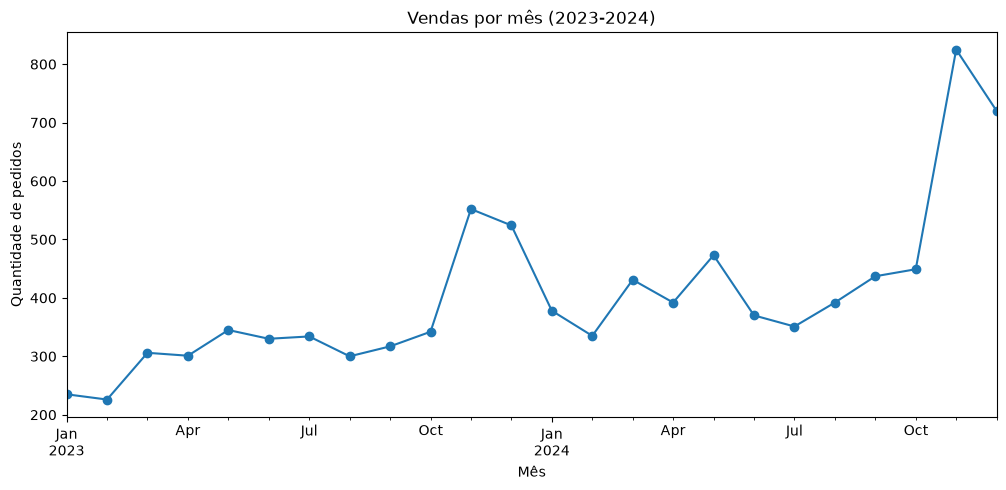

In [91]:
vendas_por_mes.plot(kind="line", figsize=(12, 5), marker="o")
plt.title("Vendas por mês (2023-2024)")
plt.xlabel("Mês")
plt.ylabel("Quantidade de pedidos")
plt.savefig("vendas_por_mes.png")
plt.show()

In [92]:
produtos_quantidade = df.groupby("produto")["quantidade"].sum().sort_values(ascending=False)

In [93]:
produtos_quantidade.head(10)

produto
Fone Bluetooth TWS         541
Smartwatch Fit             532
Webcam Full HD             520
Jaqueta Jeans              514
Carregador Turbo 30W       505
Camiseta Básica Algodão    491
Boné Aba Curva             468
Mochila Notebook 15"       449
Secador de Cabelo 2000W    447
Caixa de Som Portátil      429
Name: quantidade, dtype: int64

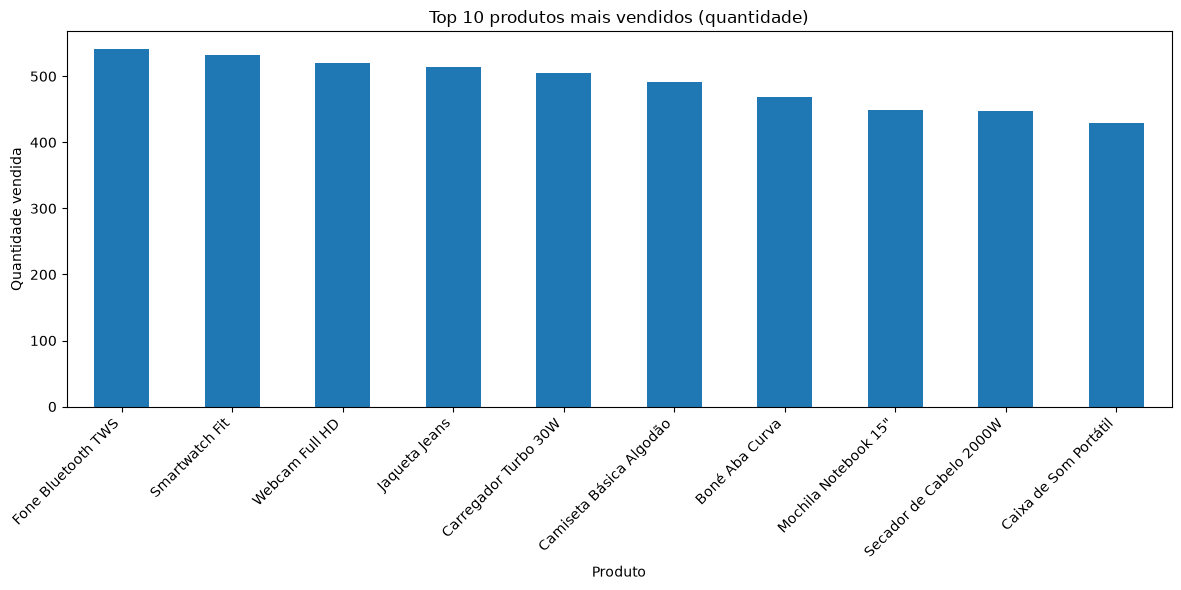

In [94]:
produtos_quantidade.head(10).plot(kind="bar", figsize=(12, 6))
plt.title("Top 10 produtos mais vendidos (quantidade)")
plt.xlabel("Produto")
plt.ylabel("Quantidade vendida")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()